# 04 — Learning-Outcome extraction (Bloom cognitive-process tagging)

**Inputs:**
- `artefacts/segments.parquet` (from notebook 03).
- `raw-data/bloom_verbs.csv` — single source of truth: per-level Slovak Bloom verb anchors (closed list, sourced from ŠŠI *Repetitórium Bloomovej taxonómie*) and one few-shot exemplar Learning Outcome per verb where available.

**Outputs:**
- `artefacts/lo_raw.parquet` — Learning Outcomes straight from GPT-4.1, before deduplication.
- `artefacts/lo_clean.parquet` — after Stage 3 cross-segment deduplication.
- `artefacts/cell_occupancy.parquet` — per-(course, lecture, cognitive_process) Learning-Outcome counts.
- `artefacts/dedup_threshold_sweep.csv` — calibration sweep that justifies the cosine threshold.
- `artefacts/figures/bloom_level_histogram.png` (per-course).

In [1]:
from pathlib import Path
import json, time
import numpy as np, pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from tqdm.auto import tqdm

load_dotenv()
OUT = Path('artefacts')
RAW = Path('raw-data')
FIG = OUT / 'figures'; FIG.mkdir(exist_ok=True, parents=True)

MODEL          = 'gpt-4.1'
SEED           = 1
EMB_MODEL      = 'text-embedding-3-small'
DEDUP_COSINE   = 0.85
DEDUP_SWEEP    = [0.75, 0.80, 0.83, 0.85, 0.88, 0.90, 0.95]

# Authoritative annotation guidelines — single source of truth shared with human annotators.
INSTRUCTIONS = (RAW / 'reference' / 'instructions_for_annotators.md').read_text()

# Calibration set: (course_id, slug-substring) -> resolved at runtime.
CALIBRATION_SLUGS = {
    (1,  'bananovy-klavir'),
    (1,  'kamen-papier-noznice'),
    (5,  'pokrocily-led-pasiky'),
    (5,  'pokrocilyvlhkost-pody'),
    (42, 'pbl-7-ucitelskych-postupov'),
}

client = OpenAI()

## Load segments + exemplars; restrict to calibration set

In [2]:
segments = pd.read_parquet(OUT / 'segments.parquet')
bloom_verbs = pd.read_csv(RAW / 'bloom_verbs.csv')

def resolve_lecture(course_id, slug_sub):
    matches = segments[(segments.course_id == course_id)
                       & (segments.lecture_id.str.contains(slug_sub, regex=False))]
    return sorted(matches.lecture_id.unique())

calibration_lecture_ids = []
for cid, slug in CALIBRATION_SLUGS:
    matches = resolve_lecture(cid, slug)
    if not matches:
        print(f'WARNING: no match for course {cid}, slug {slug}')
        continue
    # Take the first match; the IV-prefixed version belongs to course 30/32 not 5.
    if cid == 5:
        matches = [m for m in matches if not m.startswith(('01-iv-', '04-iv-', '05-iv-'))]
    if cid == 1:
        matches = [m for m in matches if not m.startswith(('04-iv-', '05-iv-'))]
    calibration_lecture_ids.append((cid, matches[0]))
    print(f'  course {cid:>2}: {matches[0]}')

calibration_keys = set(calibration_lecture_ids)
calib_segments = segments[
    segments.apply(lambda r: (r.course_id, r.lecture_id) in calibration_keys, axis=1)
].reset_index(drop=True)
print(f'\n{len(calib_segments)} segments across {len(calibration_keys)} lectures')

  course 42: 07-pbl-7-ucitelskych-postupov
  course  1: 04-kamen-papier-noznice
  course  5: 06-pokrocilyvlhkost-pody
  course  5: 01-pokrocily-led-pasiky
  course  1: 05-bananovy-klavir

30 segments across 5 lectures


## Stage 2 — LLM Learning-Outcome proposal with Bloom cognitive-process tagging


In [3]:
LO_SCHEMA = {
    'type': 'object',
    'properties': {
        'learning_outcomes': {
            'type': 'array',
            'items': {
                'type': 'object',
                'properties': {
                    'text':              {'type': 'string'},
                    'verb':              {'type': 'string'},
                    'cp_reasoning':      {'type': 'string'},
                    'cognitive_process': {'type': 'integer', 'minimum': 1, 'maximum': 6}
                },
                'required': ['text','verb','cp_reasoning','cognitive_process'],
                'additionalProperties': False
            }
        }
    },
    'required': ['learning_outcomes'],
    'additionalProperties': False,
}

# Build per-level closed verb anchors and few-shot exemplars from the single-source-of-truth CSV.
BLOOM_VERB_ANCHORS = {
    int(lvl): set(sub.verb.str.strip().str.lower())
    for lvl, sub in bloom_verbs.groupby('level')
}
BLOOM_LEVEL_NAMES = {
    int(lvl): sub.level_name_en.iloc[0]
    for lvl, sub in bloom_verbs.groupby('level')
}

def lo_consistent(lo):
    """Reject any LO whose verb is not in the anchor list for its cognitive_process."""
    return lo['verb'].strip().lower() in BLOOM_VERB_ANCHORS[lo['cognitive_process']]

# One exemplar per level: take the first row with a non-empty example for that level.
exemplar_rows = (
    bloom_verbs.dropna(subset=['example'])
               .groupby('level', as_index=False)
               .first()
               .sort_values('level')
)
exemplar_block = '\n'.join(
    f'  CP{int(r.level)} ({r.level_name_en}): "{r.example}"'
    for r in exemplar_rows.itertuples(index=False)
)

verb_pool_block = '\n'.join(
    f'  CP{lvl} ({BLOOM_LEVEL_NAMES[lvl]}): ' + ', '.join(sorted(BLOOM_VERB_ANCHORS[lvl]))
    for lvl in sorted(BLOOM_VERB_ANCHORS)
)

exemplars_section = (
    'Use the following Slovak Learning-Outcome exemplars as anchors '
    '(some levels may not have an exemplar — still emit outcomes at those '
    'levels when warranted by the segment).\n\n'
    'EXEMPLARS:\n' + exemplar_block + '\n\n'
) if exemplar_block else ''

# The annotation guidelines (instructions_for_annotators.md) are the authoritative
# specification for *both* human and LLM annotators. We embed the document verbatim
# in the system prompt; the per-level verb anchors and JSON schema below add the
# machine-readable constraints needed for structured-output enforcement.
SYSTEM_PROMPT = (
    'You are an automated annotator extracting Learning Outcomes from a Slovak educational '
    'video transcript segment. Follow the authoritative annotation instructions below — '
    'they apply equally to human and LLM annotators. Your output must comply both with these '
    'instructions and with the JSON schema requirements stated after them.\n\n'
    '===== BEGIN ANNOTATION INSTRUCTIONS (instructions_for_annotators.md) =====\n'
    + INSTRUCTIONS +
    '\n===== END ANNOTATION INSTRUCTIONS =====\n\n'
    'Schema-level constraints for your structured-output response:\n'
    '  - cognitive_process ∈ 1..6 (1=Remember, 2=Understand, 3=Apply, 4=Analyze, 5=Evaluate, 6=Create)\n'
    '  - The "verb" field must be exactly one of the canonical Slovak Bloom verb anchors '
    '(infinitive form, as listed in bloom_verbs.csv) for the assigned cognitive_process — '
    'the same infinitive that appears in the LO sentence after "vie":\n\n'
    + verb_pool_block + '\n\n'
    + exemplars_section +
    'Operational notes for the LLM annotator:\n'
    '  - Source: transcript only (the video is not available in this run).\n'
    '  - Annotation is blind: do not consult any other annotator\'s output.\n'
    '  - Each LO must be atomic, in Slovak, single sentence, max 200 chars, '
    'and clearly grounded in the segment text.\n'
    '  - For each LO, the "cp_reasoning" field must contain ONE short Slovak sentence '
    'identifying which Bloom cognitive process the LO requires and why; '
    'commit to "cognitive_process" only after the reasoning is written. '
    'Do not default to CP2 (Understand) or CP3 (Apply) without justification — '
    'pure recall belongs to CP1, decomposition to CP4, judgement to CP5, generation to CP6.\n'
)

def extract_los(segment_text: str, retries: int = 2) -> list:
    for attempt in range(retries + 1):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': f'LECTURE TRANSCRIPT:\n{segment_text}'}
                ],
                response_format={'type': 'json_schema',
                                 'json_schema': {'name': 'learning_outcomes', 'schema': LO_SCHEMA, 'strict': True}},
                temperature=0,
                seed=SEED,
            )
            return json.loads(resp.choices[0].message.content).get('learning_outcomes', [])
        except Exception as e:
            if attempt == retries:
                print(f'  failed after {retries+1} attempts: {e}')
                return []
            time.sleep(2 * (attempt + 1))
    return []

# Whole-lecture extraction: concatenate the raw Whisper transcript per calibration
# lecture and call the LLM once per lecture (instead of once per 1000-char window).
# This gives the LLM the full lecture context at the cost of losing the per-window
# segment timestamps for individual LOs.
transcripts = pd.read_parquet(OUT / 'transcripts.parquet').sort_values(
    ['course_id', 'lecture_id', 'segment_idx']
)
calib_transcripts = transcripts[
    transcripts.apply(lambda r: (r.course_id, r.lecture_id) in calibration_keys, axis=1)
]
calib_lectures = (
    calib_transcripts
    .groupby(['course_id', 'lecture_id'], sort=False)
    .agg(
        full_text=('text', lambda s: ' '.join(s.fillna('').astype(str).tolist())),
        t_start=('t_start', 'min'),
        t_end=('t_end', 'max'),
    )
    .reset_index()
)
print(f'{len(calib_lectures)} lectures, mean transcript length: '
      f'{calib_lectures.full_text.str.len().mean():.0f} chars '
      f'(min {calib_lectures.full_text.str.len().min()}, '
      f'max {calib_lectures.full_text.str.len().max()})')

raw_rows = []
for _, lec in tqdm(calib_lectures.iterrows(), total=len(calib_lectures)):
    los = extract_los(lec['full_text'])
    for i, a in enumerate(los):
        raw_rows.append({
            'segment_id':        f"{lec['lecture_id']}_full",
            'course_id':         lec['course_id'],
            'lecture_id':        lec['lecture_id'],
            'segment_t_start':   lec['t_start'],
            'segment_t_end':     lec['t_end'],
            'lo_idx':            i,
            'text':              a['text'],
            'verb':              a['verb'],
            'cp_reasoning':      a.get('cp_reasoning', ''),
            'cognitive_process': a['cognitive_process'],
        })
# === bloom_verbs.csv as the source of truth for cognitive_process ===
# The annotator workflow is verb -> level (read directly off bloom_verbs.csv).
# We mirror that here: keep the LLM's verb, but derive cognitive_process from the
# canonical CSV. LOs whose verb is not in the canonical list are dropped, matching
# the instructions' closed-list requirement (lo_consistent above).
VERB_TO_LEVELS = (
    bloom_verbs.assign(verb=bloom_verbs.verb.str.strip().str.lower())
               .groupby('verb')['level']
               .apply(lambda s: set(int(x) for x in s))
               .to_dict()
)

def cp_from_verb(verb: str, llm_cp: int) -> int:
    """Verb -> level via bloom_verbs.csv. For verbs at multiple levels (vytvoriť,
    usporiadať), accept the LLM's choice if valid; otherwise fall back to the
    highest level (per the instructions' 'najvyššiu úroveň' rule)."""
    levels = VERB_TO_LEVELS[verb.strip().lower()]
    return int(llm_cp) if int(llm_cp) in levels else max(levels)

n_total = len(raw_rows)
filtered = [r for r in raw_rows if r['verb'].strip().lower() in VERB_TO_LEVELS]
n_offlist = n_total - len(filtered)
n_overridden = 0
for r in filtered:
    new_cp = cp_from_verb(r['verb'], r['cognitive_process'])
    if new_cp != r['cognitive_process']:
        n_overridden += 1
    r['cognitive_process'] = new_cp
print(f'verb-lookup: dropped {n_offlist} off-list LOs, overrode CP on {n_overridden} of {len(filtered)}')

lo_raw = pd.DataFrame(filtered)
lo_raw['lo_id'] = (
    lo_raw.segment_id + '_lo' + lo_raw.lo_idx.astype(str).str.zfill(2)
)
lo_raw.to_parquet(OUT / 'lo_raw.parquet', index=False)
print(f'\nextracted {len(lo_raw):,} learning outcomes across {lo_raw.lecture_id.nunique()} lectures')
print(lo_raw.cognitive_process.value_counts().sort_index())

5 lectures, mean transcript length: 4533 chars (min 2676, max 6028)


  0%|          | 0/5 [00:00<?, ?it/s]

verb-lookup: dropped 1 off-list LOs, overrode CP on 1 of 55

extracted 55 learning outcomes across 5 lectures
cognitive_process
1     6
2    28
3    17
6     4
Name: count, dtype: int64


## Stage 3 — Cross-segment deduplication + threshold sweep

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

def embed_batches(texts, batch_size=64):
    out = []
    for i in tqdm(range(0, len(texts), batch_size), desc='embedding LOs'):
        chunk = texts[i:i+batch_size]
        resp = client.embeddings.create(model=EMB_MODEL, input=chunk)
        out.extend(d.embedding for d in resp.data)
    return np.array(out, dtype=np.float32)

lo_embs = embed_batches(lo_raw.text.tolist())

def dedup_los(threshold: float):
    """Within each course, merge LOs whose cosine similarity is ≥ threshold.
    Merged LO inherits the LOWER cognitive_process tag (conservative)."""
    keep_mask = np.ones(len(lo_raw), dtype=bool)
    merge_log = []  # (kept_idx, dropped_idx)
    for cid, idx in lo_raw.groupby(['course_id']).groups.items():
        idx = list(idx)
        if len(idx) < 2:
            continue
        sub_emb = lo_embs[idx]
        sim = cosine_similarity(sub_emb)
        np.fill_diagonal(sim, 0)
        # Greedy: keep the earliest-indexed LO in each cluster.
        for i in range(len(idx)):
            if not keep_mask[idx[i]]:
                continue
            for j in range(i + 1, len(idx)):
                if not keep_mask[idx[j]]:
                    continue
                if sim[i, j] >= threshold:
                    keep_mask[idx[j]] = False
                    merge_log.append((idx[i], idx[j]))
    return keep_mask, merge_log

sweep_rows = []
for tau in DEDUP_SWEEP:
    mask, log = dedup_los(tau)
    sweep_rows.append({
        'threshold': tau,
        'kept':      int(mask.sum()),
        'merged':    int((~mask).sum()),
        'merge_pairs': len(log),
    })
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(OUT / 'dedup_threshold_sweep.csv', index=False)
print(sweep)

# Apply final threshold.
keep_mask, merge_log = dedup_los(DEDUP_COSINE)
lo_clean = lo_raw.loc[keep_mask].copy().reset_index(drop=True)

# Conservative cognitive_process inheritance: for each merged group, set the kept LO's CP
# to the minimum of all CPs in that group.
if merge_log:
    by_keeper = {}
    for k, d in merge_log:
        by_keeper.setdefault(k, []).append(d)
    for k, drops in by_keeper.items():
        all_idx = [k] + drops
        min_cp = lo_raw.iloc[all_idx].cognitive_process.min()
        lo_id_k = lo_raw.iloc[k].lo_id
        lo_clean.loc[lo_clean.lo_id == lo_id_k, 'cognitive_process'] = int(min_cp)

lo_clean.to_parquet(OUT / 'lo_clean.parquet', index=False)
print(f'\nlo_raw: {len(lo_raw)}  lo_clean: {len(lo_clean)}  merged: {len(lo_raw) - len(lo_clean)}')

embedding LOs:   0%|          | 0/1 [00:00<?, ?it/s]

   threshold  kept  merged  merge_pairs
0       0.75    36      19           19
1       0.80    44      11           11
2       0.83    47       8            8
3       0.85    51       4            4
4       0.88    53       2            2
5       0.90    55       0            0
6       0.95    55       0            0

lo_raw: 55  lo_clean: 51  merged: 4


/tmp/ipykernel_63267/4181645322.py:18: Pandas4Warning: In a future version, the keys of `groups` will be a tuple with a single element, e.g. (course_id,) , instead of a scalar, e.g. course_id, when grouping by a list with a single element. Use ``df.groupby(by='a').groups`` instead of ``df.groupby(by=['a']).groups`` to avoid this warning
  for cid, idx in lo_raw.groupby(['course_id']).groups.items():
/tmp/ipykernel_63267/4181645322.py:18: Pandas4Warning: In a future version, the keys of `groups` will be a tuple with a single element, e.g. (course_id,) , instead of a scalar, e.g. course_id, when grouping by a list with a single element. Use ``df.groupby(by='a').groups`` instead of ``df.groupby(by=['a']).groups`` to avoid this warning
  for cid, idx in lo_raw.groupby(['course_id']).groups.items():
/tmp/ipykernel_63267/4181645322.py:18: Pandas4Warning: In a future version, the keys of `groups` will be a tuple with a single element, e.g. (course_id,) , instead of a scalar, e.g. course_id, w

## Stage 4 — Course-level cell occupancy + heatmap

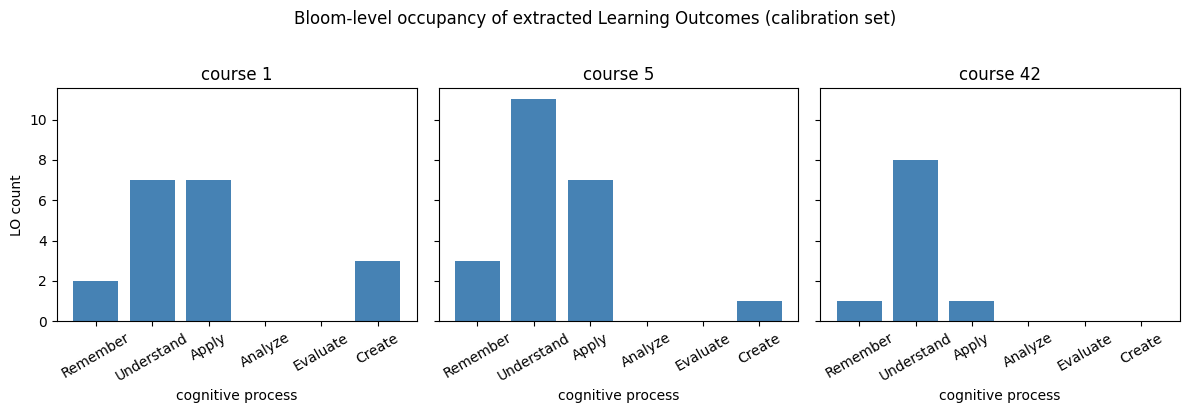

In [5]:
import seaborn as sns, matplotlib.pyplot as plt

occupancy = (
    lo_clean.groupby(['course_id','lecture_id','cognitive_process'])
               .size().rename('count').reset_index()
)
occupancy.to_parquet(OUT / 'cell_occupancy.parquet', index=False)

# Per-course Bloom-level histogram (1×6 bars).
cp_labels = ['Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'Create']
courses_present = sorted(lo_clean.course_id.unique())
fig, axes = plt.subplots(1, len(courses_present), figsize=(4 * len(courses_present), 4), sharey=True)
if len(courses_present) == 1:
    axes = [axes]
for ax, cid in zip(axes, courses_present):
    course_los = lo_clean[lo_clean.course_id == cid]
    counts = course_los.cognitive_process.value_counts().reindex(range(1, 7), fill_value=0)
    ax.bar(range(1, 7), counts.values, color='#4682B4')
    ax.set_xticks(range(1, 7))
    ax.set_xticklabels(cp_labels, rotation=30)
    ax.set_title(f'course {cid}')
    ax.set_xlabel('cognitive process')
    if cid == courses_present[0]:
        ax.set_ylabel('LO count')
fig.suptitle('Bloom-level occupancy of extracted Learning Outcomes (calibration set)', y=1.02)
fig.tight_layout()
fig.savefig(FIG / 'bloom_level_histogram.png', dpi=150, bbox_inches='tight')
plt.show()